<a href="https://colab.research.google.com/github/Maleewij65/heart-disease-prediction-ML_Assignment/blob/IT22923806_XGBoost/IT22923806_XGboost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Step 1: Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [6]:
# Step 2: Load the dataset
# To resolve FileNotFoundError, ensure 'heart.csv' is uploaded to the Colab environment.
# You can upload the file by running the following lines:
from google.colab import files
uploaded = files.upload()
# Then, ensure 'heart.csv' is present in the current directory.
df = pd.read_csv("heart.csv")  # put the CSV file in the same folder as your notebook

# Remove rows where Cholesterol is 0
df = df[df['Cholesterol'] != 0]

Saving heart.csv to heart.csv


In [7]:
# Explore the dataset
print("Shape of dataset:", df.shape)
print("First 5 rows:")
print(df.head())





Shape of dataset: (746, 12)
First 5 rows:
   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  


In [8]:
#  Check for missing values
print("\nMissing values:")
print(df.isnull().sum())



Missing values:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


In [9]:
# Data types and basic info
print("\nInfo:")
print(df.info())


Info:
<class 'pandas.core.frame.DataFrame'>
Index: 746 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             746 non-null    int64  
 1   Sex             746 non-null    object 
 2   ChestPainType   746 non-null    object 
 3   RestingBP       746 non-null    int64  
 4   Cholesterol     746 non-null    int64  
 5   FastingBS       746 non-null    int64  
 6   RestingECG      746 non-null    object 
 7   MaxHR           746 non-null    int64  
 8   ExerciseAngina  746 non-null    object 
 9   Oldpeak         746 non-null    float64
 10  ST_Slope        746 non-null    object 
 11  HeartDisease    746 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 75.8+ KB
None


In [10]:
# Summary statistics
print("\nStatistics:")
print(df.describe())


Statistics:
              Age   RestingBP  Cholesterol   FastingBS       MaxHR  \
count  746.000000  746.000000   746.000000  746.000000  746.000000   
mean    52.882038  133.022788   244.635389    0.167560  140.226542   
std      9.505888   17.282750    59.153524    0.373726   24.524107   
min     28.000000   92.000000    85.000000    0.000000   69.000000   
25%     46.000000  120.000000   207.250000    0.000000  122.000000   
50%     54.000000  130.000000   237.000000    0.000000  140.000000   
75%     59.000000  140.000000   275.000000    0.000000  160.000000   
max     77.000000  200.000000   603.000000    1.000000  202.000000   

          Oldpeak  HeartDisease  
count  746.000000    746.000000  
mean     0.901609      0.477212  
std      1.072861      0.499816  
min     -0.100000      0.000000  
25%      0.000000      0.000000  
50%      0.500000      0.000000  
75%      1.500000      1.000000  
max      6.200000      1.000000  


In [11]:
# Encode categorical variables
df_encoded = pd.get_dummies(df, drop_first=True)





In [12]:
# Separate input and output
X = df_encoded.drop("HeartDisease", axis=1)
y = df_encoded["HeartDisease"]


In [13]:
# Split into train/test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


print("Train set size:", X_train.shape)
print("Test set size:", X_test.shape)

Train set size: (596, 15)
Test set size: (150, 15)


In [14]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score







In [15]:
# Train model
model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
model.fit(X_train, y_train)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:48:33] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [16]:
# Predict
y_pred = model.predict(X_test)

In [17]:
# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8733333333333333

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.92      0.87        71
           1       0.92      0.84      0.87        79

    accuracy                           0.87       150
   macro avg       0.88      0.88      0.87       150
weighted avg       0.88      0.87      0.87       150


Confusion Matrix:
[[65  6]
 [13 66]]


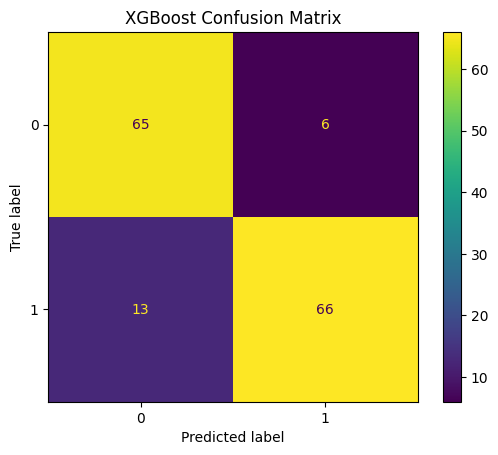

In [18]:
from sklearn.metrics import ConfusionMatrixDisplay

# Confusion Matrix Visualization
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
plt.title("XGBoost Confusion Matrix")
plt.show()

In [ ]:
# Feature Importance
importances = model.feature_importances_

# Plot feature importance
plt.figure(figsize=(10,8))
plt.barh(X.columns, importances)
plt.title("Feature Importance (XGBoost)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

In [ ]:
# Distribution of Heart Disease (target variable)
sns.countplot(x='HeartDisease', data=df)
plt.title("Distribution of Heart Disease in Dataset")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Number of Patients")
plt.show()